<a href="https://colab.research.google.com/github/CodeForFun146/30-days-projects/blob/main/logistic_and_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as df
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
sub = df.read_csv('/content/submission.csv')
test = df.read_csv('/content/test.csv')
train = df.read_csv('/content/train.csv')

In [35]:
sub

,PassengerId,Survived
0,892,False
1,893,True
2,894,False
3,895,False
4,896,True
...,...,...
413,1305,False
414,1306,True
415,1307,False
416,1308,False


In [36]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [37]:


null_counts = sub.isnull().sum()
null_counts = test.isnull().sum()
print("Null values per column:\n", null_counts)

Null values per column:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


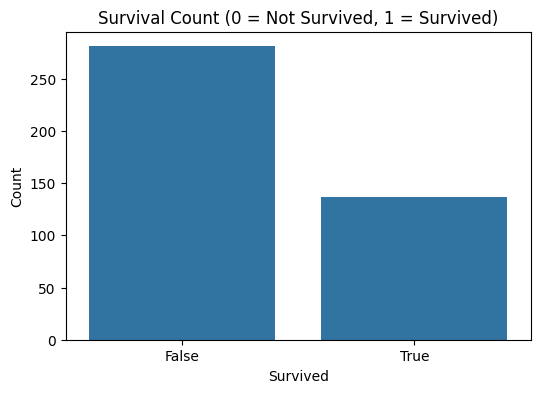

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=sub)
plt.title('Survival Count (0 = Not Survived, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

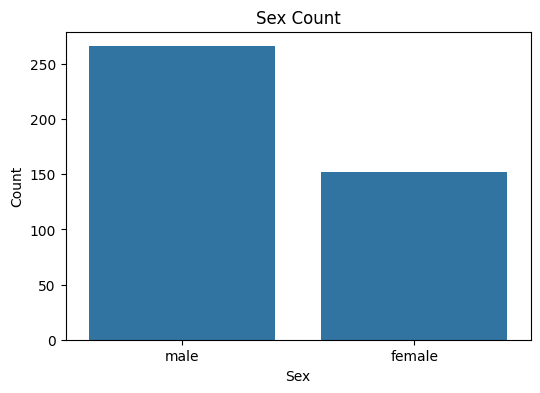

In [39]:
test = df.read_csv('/content/test.csv')
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=test)
plt.title('Sex Count')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

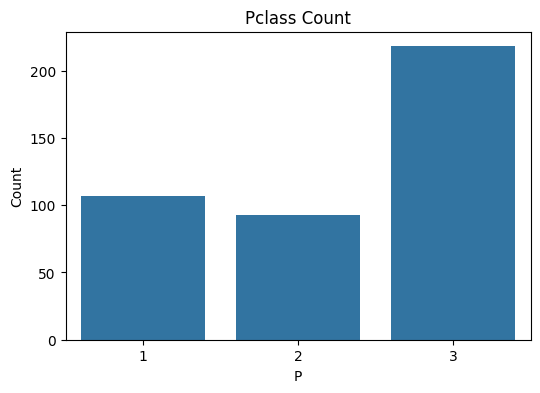

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', data=test)
plt.title('Pclass Count')
plt.xlabel('P')
plt.ylabel('Count')
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [42]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1),train['Survived'],test_size=0.30,random_state=101)


In [43]:
logmodel = LogisticRegression()

columns_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']
X_train_processed = X_train.drop(columns=columns_to_drop, errors='ignore')


if 'Age' in X_train_processed.columns:
    X_train_processed['Age'].fillna(X_train_processed['Age'].mean(), inplace=True)


if 'Fare' in X_train_processed.columns:
    X_train_processed['Fare'].fillna(X_train_processed['Fare'].mean(), inplace=True)


X_train_processed = df.get_dummies(X_train_processed, columns=['Sex', 'Embarked'], drop_first=True, dtype=float)


logmodel.fit(X_train_processed, y_train)

/tmp/ipykernel_1970/4068972886.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_processed['Age'].fillna(X_train_processed['Age'].mean(), inplace=True)
/tmp/ipykernel_1970/4068972886.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

LogisticRegression()

In [44]:
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix

In [45]:
columns_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']
X_test_processed = X_test.drop(columns=columns_to_drop, errors='ignore')


if 'Age' in X_test_processed.columns:
    X_test_processed['Age'].fillna(X_test_processed['Age'].mean(), inplace=True)

if 'Fare' in X_test_processed.columns:
    X_test_processed['Fare'].fillna(X_test_processed['Fare'].mean(), inplace=True)

X_test_processed = df.get_dummies(X_test_processed, columns=['Sex', 'Embarked'], drop_first=True, dtype=float)

predictions = logmodel.predict(X_test_processed)
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.78      0.88      0.82       154
           1       0.80      0.66      0.72       114

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.78      0.78       268



/tmp/ipykernel_1970/4279800885.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_processed['Age'].fillna(X_test_processed['Age'].mean(), inplace=True)
/tmp/ipykernel_1970/4279800885.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

**KNN**

In [54]:
classified = df.read_csv('/content/Classified Data.txt')

In [52]:
classified

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,1.010953,1.034006,0.853116,0.622460,1.036610,0.586240,0.746811,0.319752,1.117340,1.348517,1
996,996,0.575529,0.955786,0.941835,0.792882,1.414277,1.269540,1.055928,0.713193,0.958684,1.663489,0
997,997,1.135470,0.982462,0.781905,0.916738,0.901031,0.884738,0.386802,0.389584,0.919191,1.385504,1
998,998,1.084894,0.861769,0.407158,0.665696,1.608612,0.943859,0.855806,1.061338,1.277456,1.188063,1
